# Optimización Multi-Objetivo con NSGA-II y MLP: Maximizar Producción y Minimizar Consumo

Este cuaderno implementa la fase de optimización del proceso de pasteurización. Se utiliza el modelo predictivo (MLP) entrenado previamente como **función surrogate** para un **Algoritmo Genético Multi-Objetivo (NSGA-II)** implementado con `DEAP`.

**Resumen del Flujo de Trabajo:**
El algoritmo busca iterativamente el conjunto de soluciones óptimas (Frente de Pareto) que representen los mejores compromisos entre **maximizar la producción** (caudal de leche) y **minimizar el consumo energético**, garantizando siempre la seguridad alimentaria.

**Formulación Matemática del Problema (Bi-Objetivo con Restricción):**

* **Funciones Objetivo:**
$$\min f_1 = E_{consumo}(F_{flow}, T_{servicio} \mid T_{in}, t_{ciclo}, \Delta P) \quad [\text{kW}]$$
$$\max f_2 = F_{flow} \quad [\text{L/h}]$$

* **Restricción dura (vía penalización en fitness):**
$$T_{out\_leche}(F_{flow}, T_{servicio} \mid T_{in}, t_{ciclo}, \Delta P) \geq 72.3^\circ\text{C}$$

Las soluciones que no cumplan la restricción de pasteurización reciben una **penalización proporcional al déficit** de temperatura, lo que guía evolutivamente al GA hacia la zona factible.

* **Variables de Decisión (Cromosoma):**
    * $F_{flow}$: Caudal de alimentación $[3500 - 5500 \text{ L/h}]$.
    * $T_{servicio}$: Temperatura del agua de servicio $[76 - 95 ^\circ\text{C}]$.

* **Criterio de Selección:** Entre las soluciones factibles del Frente de Pareto, se selecciona aquella que minimiza el **consumo energético específico** $\frac{E_{consumo}}{F_{flow}}$ (kW por L/h), logrando el mejor balance producción-eficiencia.

* **Resultado:** Un **Frente de Pareto** que muestra el compromiso real entre producir más y consumir menos, sin sacrificar la seguridad alimentaria.

**Métricas Clave Reportadas:**
| Métrica | Símbolo | Unidades | Descripción |
|---------|---------|----------|-------------|
| Consumo energético | $E_{consumo}$ | kW | Potencia consumida por el intercambiador |
| Temperatura de salida | $T_{out\_leche}$ | °C | Temperatura de la leche pasteurizada |
| Caudal (producción) | $F_{flow}$ | L/h | Litros de leche procesados por hora |
| Consumo específico | $E/F$ | kW/(L/h) | Eficiencia: energía por unidad producida |

**Metodología:**
Basada en el enfoque híbrido ANN + GA Multi-Objetivo de *Yang et al. (2023)* — NSGA-II con Frente de Pareto — y *Abakarov et al. (2009)* para optimización térmica en procesamiento de alimentos. La formulación incluye explícitamente la maximización de la producción como objetivo, y la seguridad alimentaria como restricción penalizada en la función fitness.

In [1]:
# importaciones
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import random
import os
import time as _time
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
# ==========================================
# 1. RECUPERAR ARTEFACTOS Y CONFIGURACIÓN
# ==========================================
ARTIFACTS_DIR = "../../models/artifacts"

# 1.1 Cargar la configuración del modelo ganador
print(f"\U0001f4c2 Leyendo configuración desde {ARTIFACTS_DIR}/model_config.json...")
with open(f"{ARTIFACTS_DIR}/model_config.json", "r") as f:
    config = json.load(f)

# Extraer parámetros clave
INPUT_SIZE = config["input_size"]
OUTPUT_SIZE = config["output_size"]
NUM_LAYERS = config["num_layers"]
NEURONS = config["neurons"]
ACTIVATION = config["activation"]
FEATURES_ORDER = config["features_in_order"]
TARGETS_ORDER = config["targets_in_order"]

print(f"\u2705 Configuración cargada: MLP {INPUT_SIZE} -> {NUM_LAYERS} capas de {NEURONS} neuronas -> {OUTPUT_SIZE}")
print(f"\U0001f4cb Orden obligatorio de features: {FEATURES_ORDER}")

# 1.2 Reconstruir la Clase del Modelo
class DynamicMLP(nn.Module):
    """Red Neuronal Multicapa que se construye al vuelo según los hiperparámetros."""
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()

        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
            
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# 1.3 Instanciar modelo y cargar pesos
model = DynamicMLP(INPUT_SIZE, OUTPUT_SIZE, NUM_LAYERS, NEURONS, ACTIVATION)
try:
    model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_predictor.pt"))
    model.eval()
    print("\u2705 Pesos del modelo cargados correctamente.")
except Exception as e:
    print(f"\u274c Error cargando pesos: {e}")

# 1.4 Cargar Escaladores
scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
print("\u2705 Escaladores (X e y) cargados.")

📂 Leyendo configuración desde ../../models/artifacts/model_config.json...
✅ Configuración cargada: MLP 5 -> 4 capas de 32 neuronas -> 2
📋 Orden obligatorio de features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
✅ Pesos del modelo cargados correctamente.
✅ Escaladores (X e y) cargados.


C:\Users\vgarc\AppData\Local\Temp\ipykernel_16700\1142813354.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_pred

## Definición del Problema de Optimización Bi-Objetivo con Restricción

En estas celdas configuramos el algoritmo genético, concretamente la "caja de herramientas" (`Toolbox`) de DEAP, estableciendo la estructura biológica y las reglas matemáticas de evolución.

**Función de predicción (modelo de DL):** Recibe las variables de decisión (`F_flow`, `T_servicio`) y las condiciones externas fijas (`T_in_leche`, `t_ciclo`, `Delta_P`) y consulta al modelo MLP para obtener `E_consumo` y `T_out_leche`.

**Función de Fitness Bi-Objetivo:**
- **Objetivo 1:** Minimizar `E_consumo` (kW) → eficiencia energética.
- **Objetivo 2:** Maximizar `F_flow` (L/h) → maximizar producción.
- DEAP usa `weights=(-1.0, 1.0)` para minimizar el primero y maximizar el segundo.
- **Restricción:** `T_out_leche ≥ 72.3 °C` → seguridad alimentaria. Se aplica como **penalización proporcional al déficit** de temperatura directamente en la función fitness, lo que guía al GA hacia la zona factible sin eliminar prematuramente diversidad genética.

**Criterio de selección final:** Minimizar el consumo específico $\frac{E_{consumo}}{F_{flow}}$ $[\text{kW/(L/h)}]$ entre las soluciones factibles, lo que representa la **eficiencia energética por unidad de producción**.

> **Observación:** Al incluir `F_flow` como objetivo a maximizar, el algoritmo se ve forzado a explorar todo el rango de caudales, encontrando configuraciones que balancean producción industrial con eficiencia energética.

In [3]:
# ==========================================
# FUNCION DE PREDICCION Y FITNESS BI-OBJETIVO
# (min E_consumo, max F_flow, restriccion T_out >= 72.3 C — con margen PT100/PMO-FDA)
# ==========================================

# --- Limites del espacio de busqueda ---
BOUNDS = {
    'F_flow':     (3500.0, 5500.0),   # L/h  -- Limites operativos de la bomba
    'T_servicio': (76.0,   95.0),     # C    -- Limites de la caldera
}

# --- Restriccion de seguridad alimentaria ---
# Margen de seguridad termodinámico + tolerancia de instrumentación:
# Limit legal: 72.0°C. Setpoint: 72.3°C (+0.3°C para absorber incertidumbre
# del sensor PT100 Clase A ±0.3°C segun IEC 60751 y tolerancia PMO-FDA ±0.5°F)
T_OUT_MIN = 72.3   # C -- Temperatura minima de pasteurización con margen de seguridad

# --- Factor de penalizacion para soluciones infactibles ---
PENALTY_FACTOR = 10.0  # Severidad de la penalizacion por deficit de T_out

def predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P):
    """
    Envoltorio del modelo MLP: dado un escenario operativo completo,
    devuelve (E_consumo, T_out_leche) en unidades reales.
    """
    x_raw = np.array([[T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]])
    x_scaled = scaler_X.transform(x_raw)
    x_tensor = torch.FloatTensor(x_scaled)
    
    with torch.no_grad():
        y_scaled = model(x_tensor).numpy()
    y_real = scaler_y.inverse_transform(y_scaled)[0]
    return y_real[0], y_real[1]  # E_consumo, T_out_leche


def fitness_production_efficiency(individual, T_in_leche, t_ciclo, Delta_P):
    """
    Funcion de fitness BI-OBJETIVO con restriccion de temperatura.
    
    Objetivos (convencion DEAP multi-objetivo):
        - f1 = E_consumo   (a minimizar, weight = -1.0)
        - f2 = F_flow      (a maximizar, weight = +1.0)
    
    Restriccion:
        - T_out_leche >= 72.3 C (seguridad alimentaria con margen PT100/PMO)
        - Se aplica penalizacion proporcional al deficit de temperatura.
          Esto guia evolutivamente al GA hacia la zona factible sin
          eliminar prematuramente diversidad genetica.
    """
    F_flow, T_servicio = individual
    E_consumo, T_out = predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P)
    
# --- Manejo de restriccion via Muro de Penalizacion ---
    if T_out < T_OUT_MIN:
        deficit = T_OUT_MIN - T_out
        penalty = 1.0 + PENALTY_FACTOR * deficit
        
        # SUMAMOS 10000 de base para que sea imposible confundirlo con un consumo real factible
        E_penalized = 10000.0 + (float(E_consumo) * penalty)
        F_penalized = float(F_flow) / penalty
        return (E_penalized, F_penalized)
    
    return (float(E_consumo), float(F_flow))


print("Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.")
print(f"   Espacio de busqueda: F_flow in {BOUNDS['F_flow']}, T_servicio in {BOUNDS['T_servicio']}")
print(f"   Objetivo 1: min E_consumo (kW)")
print(f"   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION")
print(f"   Restriccion (penalizada): T_out_leche >= {T_OUT_MIN} C")
print(f"   Factor de penalizacion: {PENALTY_FACTOR}")

Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.
   Espacio de busqueda: F_flow in (3500.0, 5500.0), T_servicio in (76.0, 95.0)
   Objetivo 1: min E_consumo (kW)
   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION
   Restriccion (penalizada): T_out_leche >= 72.3 C
   Factor de penalizacion: 10.0


In [4]:
# ==========================================
# CONFIGURACION DE NSGA-II (DEAP)
# ==========================================

for cls_name in ["FitnessMulti", "Individual"]:
    if cls_name in creator.__dict__:
        del creator.__dict__[cls_name]

# --- Tipos base: BI-OBJETIVO ---
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# --- Generadores de genes (variables de decision) ---
toolbox.register("attr_F_flow", random.uniform, BOUNDS['F_flow'][0], BOUNDS['F_flow'][1])
toolbox.register("attr_T_servicio", random.uniform, BOUNDS['T_servicio'][0], BOUNDS['T_servicio'][1])

# --- Individuo = [F_flow, T_servicio] ---
toolbox.register(
    "individual", tools.initCycle, creator.Individual,
    (toolbox.attr_F_flow, toolbox.attr_T_servicio), n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Operadores geneticos ---
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutPolynomialBounded,
                  low=[BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]],
                  up=[BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]],
                  eta=20.0, indpb=0.3)

# --- NSGA-II: seleccion por dominancia + crowding distance ---
toolbox.register("select", tools.selNSGA2)

# --- Decorador para forzar limites tras cruce/mutacion ---
LOW = [BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]]
UP  = [BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]]

def checkBounds(low, up):
    """Decorador que clampea los genes a los limites permitidos."""
    def decorator(func):
        def wrapper(*args, **kw):
            offspring = func(*args, **kw)
            for child in offspring:
                for i, (lo, hi) in enumerate(zip(low, up)):
                    child[i] = max(lo, min(hi, child[i]))
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mate", checkBounds(LOW, UP))
toolbox.decorate("mutate", checkBounds(LOW, UP))

# Nuestro Problema Particular: Optimización sobre Variables No Controlables

A diferencia del algoritmo presentado en *Yang et al. (2023)*, nuestro proceso tiene **3 variables no controlables** que varían continuamente durante la operación de planta:

| Variable | Rango Operativo | Resolución de Malla | Nº Valores |
|----------|----------------|---------------------|------------|
| $T_{in\_leche}$ | $[0, 8]$ °C | 0.2 °C | 41 |
| $\Delta P$ | $[0.4, 1.0]$ bar | 0.1 bar | 7 |
| $t_{ciclo}$ | $[0, 800]$ min | 50 min | 17 |

Para cada trío $(T_{in}, \Delta P, t_{ciclo})$ el NSGA-II debe encontrar la combinación óptima $(F_{flow}^*, T_{servicio}^*)$ que minimice el consumo específico $\frac{E_{consumo}}{F_{flow}}$ respetando $T_{out} \geq 72.3\,°C$.

**Justificación del número de generaciones:** El análisis de convergencia realizado en el notebook de *Tuning* sobre 125 escenarios representativos demostró que el **percentil 95 de saturación evolutiva es de 8 generaciones**. Fijamos conservadoramente `n_gen = 15` como margen de seguridad, reduciendo drásticamente el coste computacional sin sacrificar calidad de solución.

**Resultado esperado:** Una **tabla de consulta (Lookup Table)**, donde cada fila contiene los setpoints óptimos $(F_{flow}^*, T_{servicio}^*)$ para unas condiciones externas dadas. Esta tabla puede desplegarse en un sistema IIoT/SCADA para proporcionar recomendaciones en tiempo real.

In [5]:
# ==============================================================================
# CONFIGURACIÓN DE LA MALLA DE ESCENARIOS Y PARÁMETROS GA
# ==============================================================================
import itertools
import time

# --- Malla de variables no controlables ---
T_in_vals    = np.round(np.arange(0.0, 8.01, 0.2), 1)    # 0.0, 0.2, ..., 8.0  → 41 valores
dp_vals      = np.round(np.arange(0.4, 1.01, 0.1), 1)     # 0.4, 0.5, ..., 1.0  → 7 valores
t_ciclo_vals = np.arange(0, 801, 50)                       # 0, 50, ..., 800     → 1 valores

escenarios = list(itertools.product(T_in_vals, dp_vals, t_ciclo_vals))

# --- Parámetros del GA (justificados por análisis de convergencia) ---
GA_OPT = {
    'pop_size': 120,
    'lambda_': 100,
    'n_gen': 15,       # Justificado en la optimizacion de hiperparams
    'cxpb': 0.9,
    'mutpb': 0.1,
}

print(f"Malla de escenarios definida:")
print(f"   T_in_leche:  {T_in_vals[0]} a {T_in_vals[-1]} °C  (paso 0.2°C)  → {len(T_in_vals)} valores")
print(f"   Delta_P:     {dp_vals[0]} a {dp_vals[-1]} bar  (paso 0.1 bar)  → {len(dp_vals)} valores")
print(f"   t_ciclo:     {t_ciclo_vals[0]} a {t_ciclo_vals[-1]} min  (paso 10 min)  → {len(t_ciclo_vals)} valores")
print(f"   TOTAL:       {len(T_in_vals)} × {len(dp_vals)} × {len(t_ciclo_vals)} = {len(escenarios):,} escenarios")
print(f"\nParámetros GA por escenario:")
print(f"   Población: {GA_OPT['pop_size']} | Hijos: {GA_OPT['lambda_']} | Generaciones: {GA_OPT['n_gen']}")
print(f"   P(cruce): {GA_OPT['cxpb']} | P(mutación): {GA_OPT['mutpb']}")

Malla de escenarios definida:
   T_in_leche:  0.0 a 8.0 °C  (paso 0.2°C)  → 41 valores
   Delta_P:     0.4 a 1.0 bar  (paso 0.1 bar)  → 7 valores
   t_ciclo:     0 a 800 min  (paso 10 min)  → 17 valores
   TOTAL:       41 × 7 × 17 = 4,879 escenarios

Parámetros GA por escenario:
   Población: 120 | Hijos: 100 | Generaciones: 15
   P(cruce): 0.9 | P(mutación): 0.1


**NOTA IMPORTANTE**: vamos a calcular el individuo ideal (optimizacion con el GA) de combinaciones que en la vida real no pueden darse ya que delta_p y tiempo de ciclo estas directamente relacionadas, es decir, no puede haber un deta_p =1 y un t_ciclo = 0 ya que significaria que hay un aumento de la presion debido al fouling nada mas arrancar la pasteurización. 

Justificación técnica: *Se calculó el producto cartesiano completo para generar una matriz regular y densa (sin huecos o NaNs) en la Lookup Table. Los autómatas industriales (PLCs) y los sistemas SCADA necesitan espacios de memoria continuos para realizar búsquedas o interpolaciones en tiempo real ($O(1)$) de forma segura. Si el sensor de presión falla un día y da un pico anómalo, el PLC no puede encontrarse un 'hueco vacío' en la tabla; necesita una respuesta robusta. Rellenar toda la caja límite del espacio paramétrico garantiza tolerancia a fallos en producción*

Aunque esto realmente no es una malla que se vaya a implementar en el PCL ya que la idea es que este proceso fuese ejecutado en tiempo real si existiese el proceso de pasteurización.

## Ejecución de la Optimización Masiva

Se ejecuta NSGA-II sobre los **escenarios** de la malla. Para cada trío de variables no controlables $(T_{in}, \Delta P, t_{ciclo})$:

1. Se inicializa una población de 120 individuos $[F_{flow}, T_{servicio}]$.
2. Se evoluciona durante 15 generaciones con NSGA-II (`eaMuPlusLambda`).
3. Se extrae el **Frente de Pareto** de la población final.
4. Se selecciona la solución factible ($T_{out} \geq 72.3\,°C$) que minimiza el **consumo específico** $\frac{E_{consumo}}{F_{flow}}$.

El progreso se reporta cada 1,000 escenarios. Los resultados se guardan incrementalmente para tolerancia a fallos.

In [6]:
# ==============================================================================
# EJECUCIÓN DE NSGA-II 
# ==============================================================================

# Archivo de salida (guardado incremental)
OUTPUT_CSV = "../../data/predictions/ga_v3_optimization_results.csv"

# Semilla global para reproducibilidad
MASTER_SEED = 1

resultados = []

print(f"🚀 Iniciando optimización masiva: {len(escenarios):,} escenarios")
print(f"   GA config: pop={GA_OPT['pop_size']}, λ={GA_OPT['lambda_']}, gen={GA_OPT['n_gen']}")
print(f"   Archivo de salida: {OUTPUT_CSV}")
print("=" * 70)

t_global_start = time.time()

pbar = tqdm(enumerate(escenarios), total=len(escenarios), desc="Optimización NSGA-II",
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
            unit="esc")

for idx, (t_in, dp, t_ciclo) in pbar:
    
    # Semilla reproducible por escenario
    seed = MASTER_SEED + idx
    random.seed(seed)
    np.random.seed(seed)
    
    # Registrar función fitness con las condiciones externas de este escenario
    toolbox.register("evaluate", fitness_production_efficiency,
                     T_in_leche=float(t_in), t_ciclo=int(t_ciclo), Delta_P=float(dp))
    
    # Inicializar población
    pop = toolbox.population(n=GA_OPT['pop_size'])
    
    # Evaluar población inicial
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit
    
    # Evolución con eaMuPlusLambda (sin verbose para velocidad)
    for gen in range(GA_OPT['n_gen']):
        offspring = algorithms.varOr(pop, toolbox, lambda_=GA_OPT['lambda_'],
                                     cxpb=GA_OPT['cxpb'], mutpb=GA_OPT['mutpb'])
        
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        
        pop[:] = toolbox.select(pop + offspring, GA_OPT['pop_size'])
    
    # --- Extraer Frente de Pareto y seleccionar mejor solución ---
    pareto_front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    
    best_solution = None
    best_consumo_esp = float('inf')
    
    for ind in pareto_front:
        F_flow_val, T_servicio_val = ind
        E_real, T_out_real = predict_with_model(
            F_flow_val, T_servicio_val, float(t_in), int(t_ciclo), float(dp)
        )
        
        e_real = float(E_real)
        t_out_real = float(T_out_real)
        
        # Solo considerar soluciones factibles
        if t_out_real >= T_OUT_MIN:
            consumo_esp = e_real / max(F_flow_val, 1.0)
            if consumo_esp < best_consumo_esp:
                best_consumo_esp = consumo_esp
                best_solution = {
                    'F_flow': F_flow_val,
                    'T_servicio': T_servicio_val,
                    'E_consumo': e_real,
                    'T_out': t_out_real,
                    'consumo_especifico': consumo_esp,
                    'factible': True,
                    'n_pareto': len(pareto_front)
                }
    
    # Si no hay solución factible, tomar la de menor penalización
    if best_solution is None:
        for ind in pareto_front:
            F_flow_val, T_servicio_val = ind
            E_real, T_out_real = predict_with_model(
                F_flow_val, T_servicio_val, float(t_in), int(t_ciclo), float(dp)
            )
            consumo_esp = float(E_real) / max(F_flow_val, 1.0)
            if consumo_esp < best_consumo_esp:
                best_consumo_esp = consumo_esp
                best_solution = {
                    'F_flow': F_flow_val,
                    'T_servicio': T_servicio_val,
                    'E_consumo': float(E_real),
                    'T_out': float(T_out_real),
                    'consumo_especifico': consumo_esp,
                    'factible': False,
                    'n_pareto': len(pareto_front)
                }
    
    resultados.append({
        'id_escenario': idx + 1,
        'T_in_leche': float(t_in),
        'Delta_P': float(dp),
        't_ciclo': int(t_ciclo),
        'F_flow_optimo': round(best_solution['F_flow'], 2),
        'T_servicio_optimo': round(best_solution['T_servicio'], 2),
        'E_consumo_pred': round(best_solution['E_consumo'], 4),
        'T_out_pred': round(best_solution['T_out'], 2),
        'consumo_especifico': round(best_solution['consumo_especifico'], 6),
        'factible': best_solution['factible'],
        'n_soluciones_pareto': best_solution['n_pareto']
    })
    
    # Actualizar info extra en la barra de progreso cada 500 escenarios
    if (idx + 1) % 500 == 0:
        pct_fact = sum(1 for r in resultados if r['factible']) / len(resultados) * 100
        pbar.set_postfix_str(f"factibles={pct_fact:.1f}%")

    # Guardado incremental cada 5000 escenarios
    if (idx + 1) % 5000 == 0:
        df_parcial = pd.DataFrame(resultados)
        df_parcial.to_csv(OUTPUT_CSV, index=False)
        pbar.write(f"   💾 Checkpoint guardado: {idx+1:,} escenarios → {OUTPUT_CSV}")

pbar.close()

# --- Guardado final ---
t_total = time.time() - t_global_start
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(OUTPUT_CSV, index=False)

n_factibles = df_resultados['factible'].sum()
n_total = len(df_resultados)

print("\n" + "=" * 70)
print("✅ OPTIMIZACIÓN MASIVA COMPLETADA")
print("=" * 70)
print(f"   Escenarios procesados:  {n_total:,}")
print(f"   Soluciones factibles:   {n_factibles:,} ({n_factibles/n_total*100:.1f}%)")
print(f"   Soluciones infactibles: {n_total - n_factibles:,} ({(n_total-n_factibles)/n_total*100:.1f}%)")
print(f"   Tiempo total:           {t_total:.1f}s ({t_total/60:.1f} min)")
print(f"   Velocidad media:        {n_total/t_total:.1f} escenarios/s")
print(f"   Archivo guardado:       {OUTPUT_CSV}")

🚀 Iniciando optimización masiva: 4,879 escenarios
   GA config: pop=120, λ=100, gen=15
   Archivo de salida: ../../data/predictions/ga_v3_optimization_results.csv


Optimización NSGA-II:   0%|          | 0/4879 [00:00<?, ?esc/s]


✅ OPTIMIZACIÓN MASIVA COMPLETADA
   Escenarios procesados:  4,879
   Soluciones factibles:   4,879 (100.0%)
   Soluciones infactibles: 0 (0.0%)
   Tiempo total:           3944.1s (65.7 min)
   Velocidad media:        1.2 escenarios/s
   Archivo guardado:       ../../data/predictions/ga_v3_optimization_results.csv


## Análisis Exploratorio de Resultados

Una vez completada la optimización masiva, analizamos la **Lookup Table** generada para verificar la calidad de las soluciones y extraer patrones operativos relevantes para la planta de pasteurización.

In [7]:
# ==============================================================================
# ANÁLISIS EXPLORATORIO DE LA LOOKUP TABLE
# ==============================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Cargar resultados (por si se reinicia el kernel)
df_resultados = pd.read_csv("../../data/predictions/ga_v3_optimization_results.csv")

print(f"📊 Lookup Table cargada: {len(df_resultados):,} escenarios")
print(f"   Factibles: {df_resultados['factible'].sum():,} ({df_resultados['factible'].mean()*100:.1f}%)")

print(f"\n--- Estadísticas descriptivas ---")
display(df_resultados[['F_flow_optimo', 'T_servicio_optimo', 'E_consumo_pred', 
                         'T_out_pred', 'consumo_especifico']].describe().round(4))

📊 Lookup Table cargada: 4,879 escenarios
   Factibles: 4,879 (100.0%)

--- Estadísticas descriptivas ---


,F_flow_optimo,T_servicio_optimo,E_consumo_pred,T_out_pred,consumo_especifico
count,4879.0000,4879.0000,4879.0000,4879.0000,4879.0000
mean,5380.8741,80.7978,369.0949,72.3037,0.0686
std,171.7783,1.0758,20.5302,0.0060,0.0022
min,4793.5100,77.4300,311.2625,72.3000,0.0634
25%,5335.4000,80.1100,357.2238,72.3000,0.0668
50%,5469.1700,80.8700,374.7835,72.3000,0.0687
75%,5500.0000,81.6500,385.2678,72.3100,0.0704
max,5500.0000,82.8900,399.8674,72.3400,0.0730


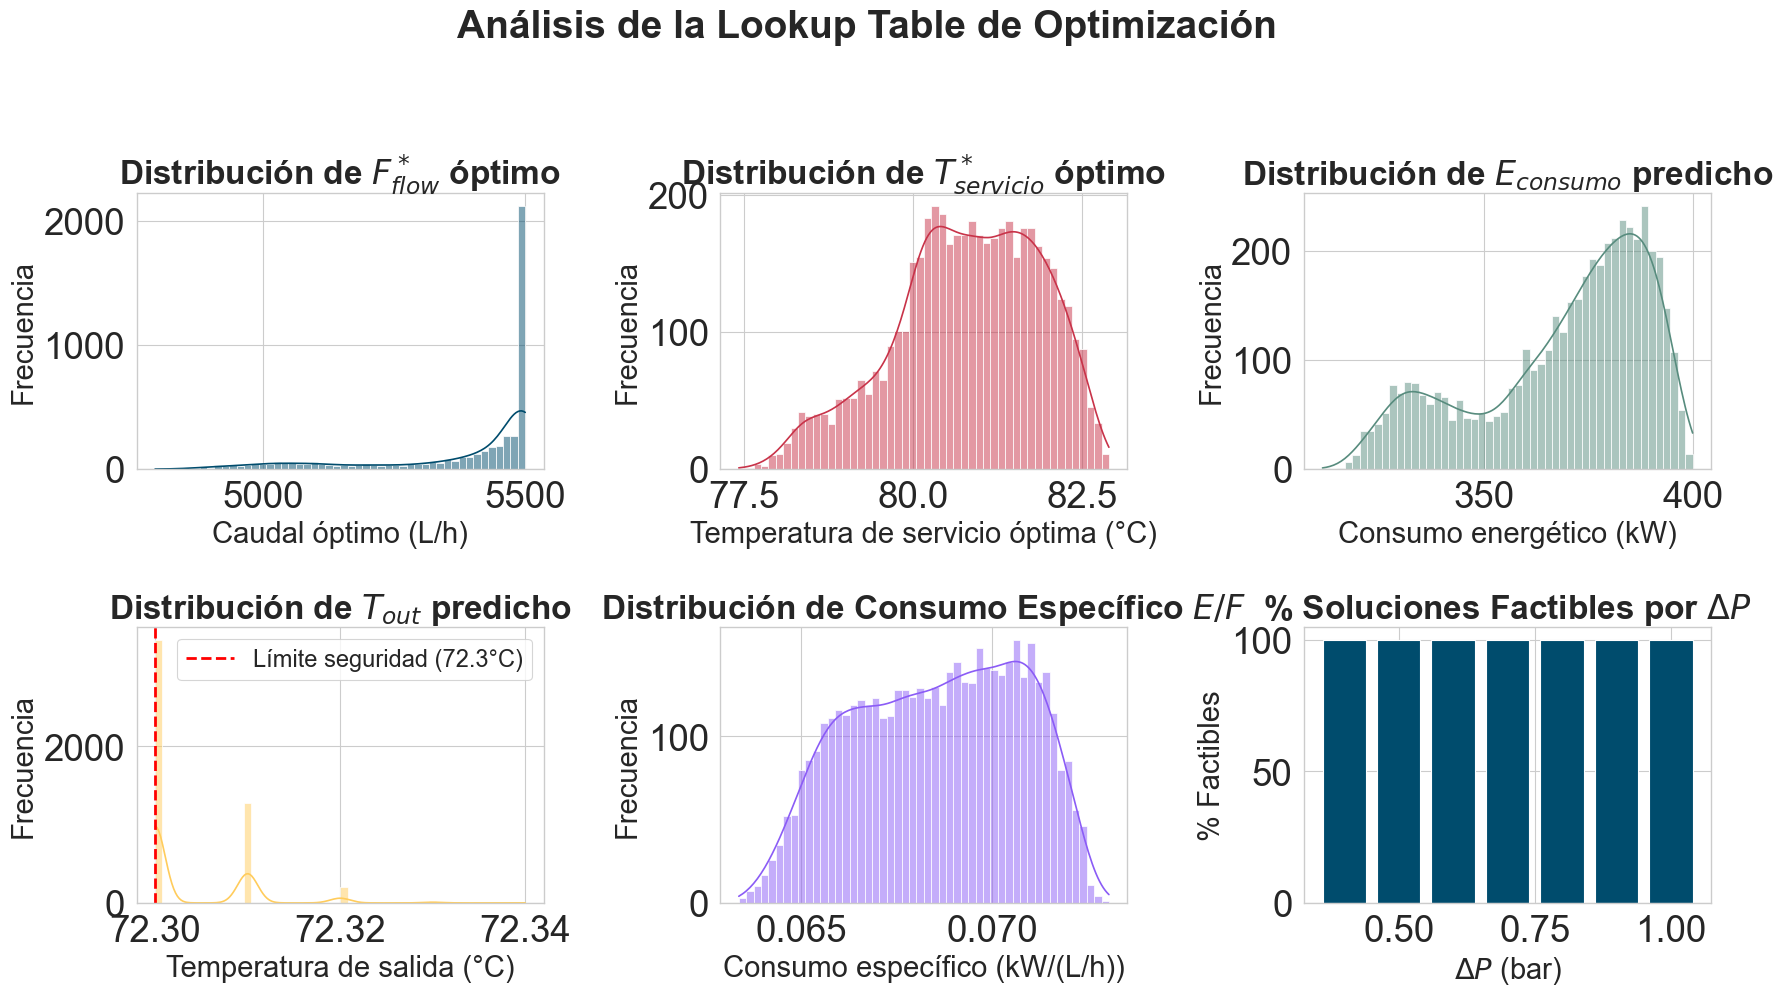

In [8]:
#, ==============================================================================
# VISUALIZACIÓN 1: Distribuciones de las Variables Óptimas
# ==============================================================================
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 21,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 17,
    'figure.titlesize': 26,
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

sns.set_theme(style="whitegrid", context="paper", font_scale=3.0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='none')
fig.patch.set_alpha(0)

for ax in axes.flat:
    ax.set_facecolor('none')
    ax.patch.set_alpha(0)

# Solo escenarios factibles para las distribuciones
df_fact = df_resultados[df_resultados['factible'] == True].copy()

# 1.1 Distribución de F_flow óptimo
sns.histplot(df_fact['F_flow_optimo'], kde=True, ax=axes[0, 0], color='#004c6d', bins=50)
axes[0, 0].set_title('Distribución de $F_{flow}^*$ óptimo', fontweight='bold', fontsize=24)
axes[0, 0].set_xlabel('Caudal óptimo (L/h)', fontsize=21)
axes[0, 0].set_ylabel('Frecuencia', fontsize=21)

# 1.2 Distribución de T_servicio óptimo
sns.histplot(df_fact['T_servicio_optimo'], kde=True, ax=axes[0, 1], color='#c83349', bins=50)
axes[0, 1].set_title('Distribución de $T_{servicio}^*$ óptimo', fontweight='bold', fontsize=24)
axes[0, 1].set_xlabel('Temperatura de servicio óptima (°C)', fontsize=21)
axes[0, 1].set_ylabel('Frecuencia', fontsize=21)

# 1.3 Distribución de E_consumo predicho
sns.histplot(df_fact['E_consumo_pred'], kde=True, ax=axes[0, 2], color='#588c7e', bins=50)
axes[0, 2].set_title('Distribución de $E_{consumo}$ predicho', fontweight='bold', fontsize=24)
axes[0, 2].set_xlabel('Consumo energético (kW)', fontsize=21)
axes[0, 2].set_ylabel('Frecuencia', fontsize=21)

# 1.4 Distribución de T_out predicha
sns.histplot(df_fact['T_out_pred'], kde=True, ax=axes[1, 0], color='#ffcc5c', bins=50)
axes[1, 0].axvline(x=72.3, color='red', linestyle='--', linewidth=2, label='Límite seguridad (72.3°C)')
axes[1, 0].set_title('Distribución de $T_{out}$ predicho', fontweight='bold', fontsize=24)
axes[1, 0].set_xlabel('Temperatura de salida (°C)', fontsize=21)
axes[1, 0].set_ylabel('Frecuencia', fontsize=21)
axes[1, 0].legend(fontsize=17)

# 1.5 Distribución de consumo específico
sns.histplot(df_fact['consumo_especifico'], kde=True, ax=axes[1, 1], color='#8B5CF6', bins=50)
axes[1, 1].set_title('Distribución de Consumo Específico $E/F$', fontweight='bold', fontsize=24)
axes[1, 1].set_xlabel('Consumo específico (kW/(L/h))', fontsize=21)
axes[1, 1].set_ylabel('Frecuencia', fontsize=21)

# 1.6 Factibilidad por Delta_P
factibilidad_dp = df_resultados.groupby('Delta_P')['factible'].mean() * 100
axes[1, 2].bar(factibilidad_dp.index, factibilidad_dp.values, width=0.08, color='#004c6d', edgecolor='white')
axes[1, 2].set_title('% Soluciones Factibles por $\\Delta P$', fontweight='bold', fontsize=24)
axes[1, 2].set_xlabel('$\\Delta P$ (bar)', fontsize=21)
axes[1, 2].set_ylabel('% Factibles', fontsize=21)
axes[1, 2].set_ylim(0, 105)

plt.suptitle('Análisis de la Lookup Table de Optimización', 
             fontsize=28, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/images/ga_v3_distribuciones.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none', edgecolor='none')
plt.show()

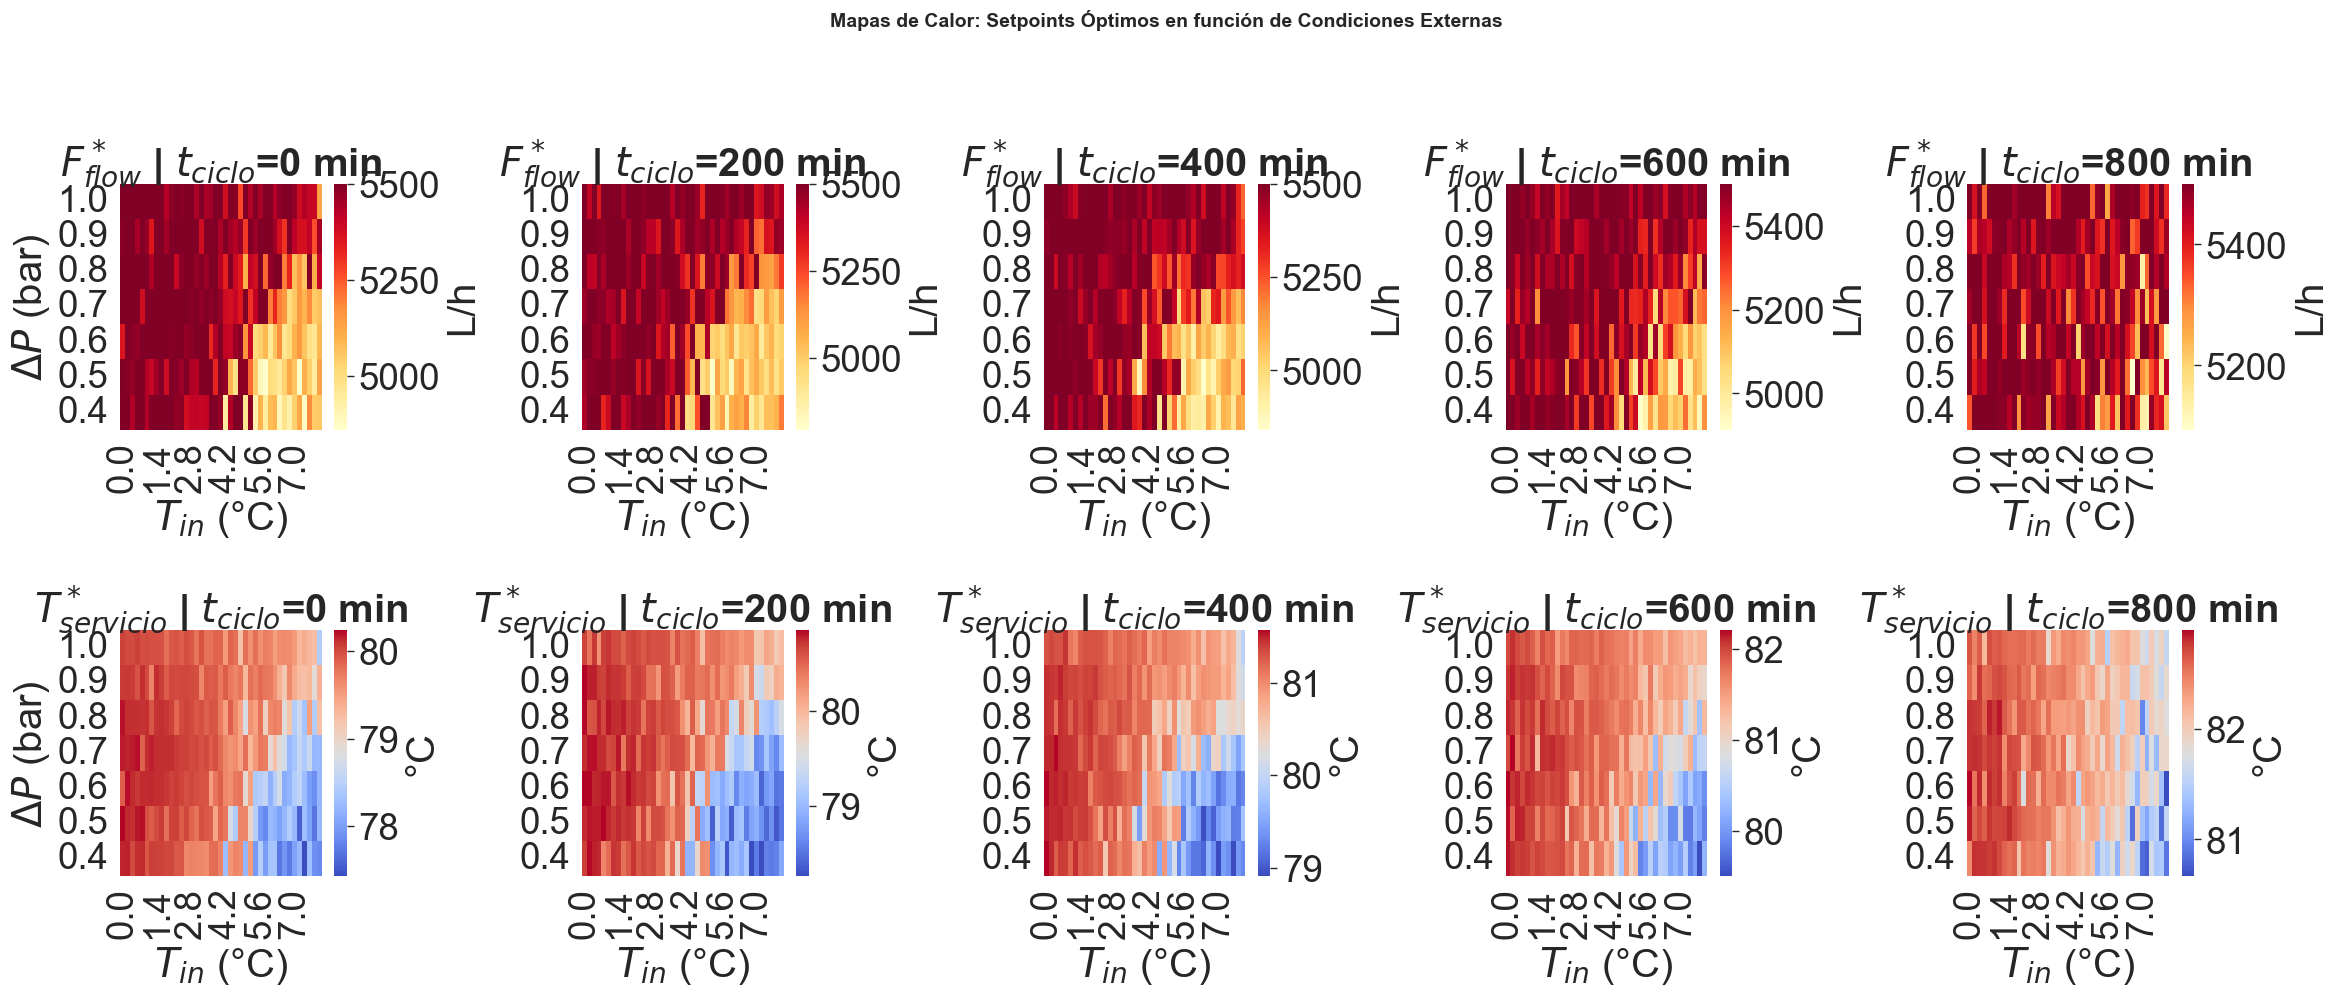

In [9]:
# ==============================================================================
# VISUALIZACIÓN 2: Mapas de Calor — Setpoints Óptimos vs Condiciones Externas
# ==============================================================================

# Seleccionar valores de t_ciclo representativos para los heatmaps
t_ciclo_slices = [0, 200, 400, 600, 800]

fig, axes = plt.subplots(2, len(t_ciclo_slices), figsize=(24, 10))

for col, t_c in enumerate(t_ciclo_slices):
    df_slice = df_fact[df_fact['t_ciclo'] == t_c]
    
    if len(df_slice) == 0:
        continue
    
    # Heatmap F_flow óptimo
    pivot_F = df_slice.pivot_table(index='Delta_P', columns='T_in_leche', 
                                    values='F_flow_optimo', aggfunc='mean')
    sns.heatmap(pivot_F, ax=axes[0, col], cmap='YlOrRd', fmt='.0f',
                cbar_kws={'label': 'L/h'}, annot=False)
    axes[0, col].set_title(f'$F_{{flow}}^*$ | $t_{{ciclo}}$={t_c} min', fontweight='bold')
    axes[0, col].set_xlabel('$T_{in}$ (°C)')
    axes[0, col].set_ylabel('$\Delta P$ (bar)' if col == 0 else '')
    axes[0, col].invert_yaxis()
    
    # Heatmap T_servicio óptimo
    pivot_T = df_slice.pivot_table(index='Delta_P', columns='T_in_leche', 
                                    values='T_servicio_optimo', aggfunc='mean')
    sns.heatmap(pivot_T, ax=axes[1, col], cmap='coolwarm', fmt='.1f',
                cbar_kws={'label': '°C'}, annot=False)
    axes[1, col].set_title(f'$T_{{servicio}}^*$ | $t_{{ciclo}}$={t_c} min', fontweight='bold')
    axes[1, col].set_xlabel('$T_{in}$ (°C)')
    axes[1, col].set_ylabel('$\Delta P$ (bar)' if col == 0 else '')
    axes[1, col].invert_yaxis()

plt.suptitle('Mapas de Calor: Setpoints Óptimos en función de Condiciones Externas', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/images/ga_v3_heatmaps_setpoints.png', dpi=300, bbox_inches='tight')
plt.show()

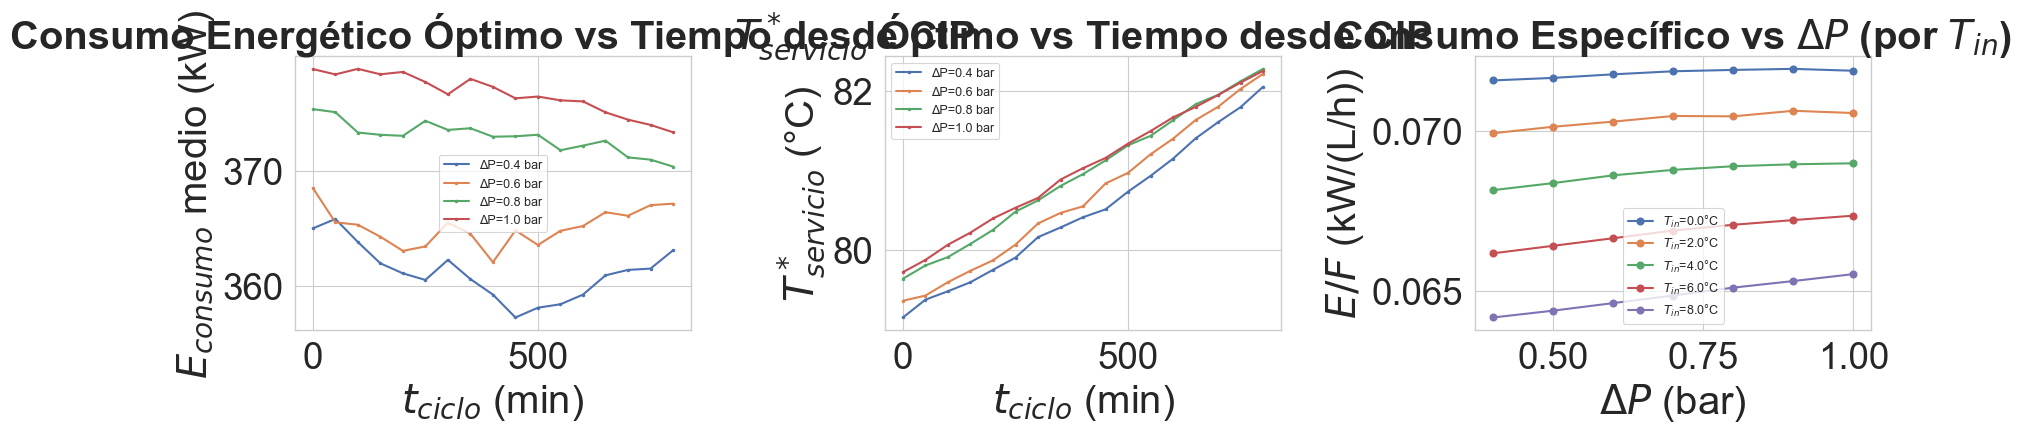

In [10]:
# ==============================================================================
# VISUALIZACIÓN 3: Impacto del Fouling en el Consumo Energético Óptimo
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 E_consumo vs t_ciclo (agrupado por Delta_P)
for dp_val in [0.4, 0.6, 0.8, 1.0]:
    df_dp = df_fact[np.isclose(df_fact['Delta_P'], dp_val)]
    grouped = df_dp.groupby('t_ciclo')['E_consumo_pred'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='.', markersize=3, 
                 label=f'ΔP={dp_val} bar', linewidth=1.5)

axes[0].set_title('Consumo Energético Óptimo vs Tiempo desde CIP', fontweight='bold')
axes[0].set_xlabel('$t_{ciclo}$ (min)')
axes[0].set_ylabel('$E_{consumo}$ medio (kW)')
axes[0].legend(fontsize=9)

# 3.2 T_servicio óptimo vs t_ciclo
for dp_val in [0.4, 0.6, 0.8, 1.0]:
    df_dp = df_fact[np.isclose(df_fact['Delta_P'], dp_val)]
    grouped = df_dp.groupby('t_ciclo')['T_servicio_optimo'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='.', markersize=3,
                 label=f'ΔP={dp_val} bar', linewidth=1.5)

axes[1].set_title('$T_{servicio}^*$ Óptimo vs Tiempo desde CIP', fontweight='bold')
axes[1].set_xlabel('$t_{ciclo}$ (min)')
axes[1].set_ylabel('$T_{servicio}^*$ (°C)')
axes[1].legend(fontsize=9)

# 3.3 Consumo específico vs Delta_P (agrupado por T_in)
for t_in_val in [0.0, 2.0, 4.0, 6.0, 8.0]:
    df_tin = df_fact[np.isclose(df_fact['T_in_leche'], t_in_val)]
    grouped = df_tin.groupby('Delta_P')['consumo_especifico'].mean()
    axes[2].plot(grouped.index, grouped.values, marker='o', 
                 label=f'$T_{{in}}$={t_in_val}°C', linewidth=1.5)

axes[2].set_title('Consumo Específico vs $\Delta P$ (por $T_{in}$)', fontweight='bold')
axes[2].set_xlabel('$\Delta P$ (bar)')
axes[2].set_ylabel('$E/F$ (kW/(L/h))')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../../data/images/ga_v3_fouling_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## Guardado de Artefactos y Reporte Final

Se genera un informe JSON con las métricas clave de la optimización y se guarda la Lookup Table final como CSV para su consumo por el sistema SCADA/IIoT.

**Artefactos generados:**
- `data/predictions/ga_v3_optimization_results.csv` — Lookup Table completa (23,247 filas)
- `models/metrics/ga_v3_optimization_report.json` — Reporte técnico de la optimización
- `data/images/ga_v3_*.png` — Visualizaciones del análisis

In [11]:
# ==============================================================================
# REPORTE FINAL Y GUARDADO DE ARTEFACTOS
# ==============================================================================

# Cargar resultados (robustez ante reinicio de kernel)
df_resultados = pd.read_csv("../../data/predictions/ga_v3_optimization_results.csv")
df_fact = df_resultados[df_resultados['factible'] == True].copy()

# --- Métricas resumen ---
report = {
    "version": "v3",
    "descripcion": "Optimización NSGA-II sobre malla completa de variables no controlables",
    "malla": {
        "T_in_leche": {"min": 0.0, "max": 8.0, "paso": 0.2, "n_valores": 41},
        "Delta_P":    {"min": 0.4, "max": 1.0, "paso": 0.1, "n_valores": 7},
        "t_ciclo":    {"min": 0, "max": 800, "paso": 50, "n_valores": 17}
    },
    "ga_config": {
        "algoritmo": "NSGA-II (eaMuPlusLambda)",
        "pop_size": 120,
        "lambda": 100,
        "n_gen": GA_OPT['n_gen'],
        "cxpb": 0.9,
        "mutpb": 0.1,
        "justificacion_n_gen": "P95 convergencia = 8 gen (análisis 125 escenarios) + margen seguridad"
    },
    "resultados": {
        "total_escenarios": int(len(df_resultados)),
        "escenarios_factibles": int(df_resultados['factible'].sum()),
        "pct_factibles": round(float(df_resultados['factible'].mean() * 100), 2),
        "F_flow_optimo": {
            "media": round(float(df_fact['F_flow_optimo'].mean()), 2),
            "min": round(float(df_fact['F_flow_optimo'].min()), 2),
            "max": round(float(df_fact['F_flow_optimo'].max()), 2),
            "std": round(float(df_fact['F_flow_optimo'].std()), 2)
        },
        "T_servicio_optimo": {
            "media": round(float(df_fact['T_servicio_optimo'].mean()), 2),
            "min": round(float(df_fact['T_servicio_optimo'].min()), 2),
            "max": round(float(df_fact['T_servicio_optimo'].max()), 2),
            "std": round(float(df_fact['T_servicio_optimo'].std()), 2)
        },
        "E_consumo_pred": {
            "media": round(float(df_fact['E_consumo_pred'].mean()), 4),
            "min": round(float(df_fact['E_consumo_pred'].min()), 4),
            "max": round(float(df_fact['E_consumo_pred'].max()), 4)
        },
        "consumo_especifico": {
            "media": round(float(df_fact['consumo_especifico'].mean()), 6),
            "min": round(float(df_fact['consumo_especifico'].min()), 6),
            "max": round(float(df_fact['consumo_especifico'].max()), 6)
        }
    },
    "restriccion": {
        "T_out_min_requerido": 72.3,
        "T_out_min_obtenido": round(float(df_fact['T_out_pred'].min()), 2),
        "T_out_media": round(float(df_fact['T_out_pred'].mean()), 2),
        "cumplimiento_100pct": bool(df_fact['T_out_pred'].min() >= 72.3)
    }
}

# Guardar reporte JSON
report_path = "../../models/metrics/ga_v3_optimization_report.json"
with open(report_path, 'w') as f:
    json.dump(report, f, indent=4, ensure_ascii=False)

print("=" * 70)
print("📋 REPORTE FINAL DE OPTIMIZACIÓN — DATAGIA v3")
print("=" * 70)
print(f"\n🔧 Configuración:")
print(f"   Escenarios totales:     {report['resultados']['total_escenarios']:,}")
print(f"   Factibles:              {report['resultados']['escenarios_factibles']:,} "
      f"({report['resultados']['pct_factibles']}%)")
print(f"   Generaciones por esc.:  {report['ga_config']['n_gen']}")

print(f"\n📊 Setpoints Óptimos (escenarios factibles):")
print(f"   F_flow*:      {report['resultados']['F_flow_optimo']['media']:.1f} ± "
      f"{report['resultados']['F_flow_optimo']['std']:.1f} L/h  "
      f"[{report['resultados']['F_flow_optimo']['min']:.1f}, "
      f"{report['resultados']['F_flow_optimo']['max']:.1f}]")
print(f"   T_servicio*:  {report['resultados']['T_servicio_optimo']['media']:.1f} ± "
      f"{report['resultados']['T_servicio_optimo']['std']:.1f} °C  "
      f"[{report['resultados']['T_servicio_optimo']['min']:.1f}, "
      f"{report['resultados']['T_servicio_optimo']['max']:.1f}]")

print(f"\n⚡ Consumo Energético:")
print(f"   E_consumo:    [{report['resultados']['E_consumo_pred']['min']:.2f}, "
      f"{report['resultados']['E_consumo_pred']['max']:.2f}] kW  "
      f"(media: {report['resultados']['E_consumo_pred']['media']:.2f} kW)")
print(f"   E/F:          [{report['resultados']['consumo_especifico']['min']:.6f}, "
      f"{report['resultados']['consumo_especifico']['max']:.6f}] kW/(L/h)")

print(f"\n🔒 Seguridad Alimentaria:")
print(f"   T_out mínimo: {report['restriccion']['T_out_min_obtenido']:.2f} °C "
      f"(req: ≥{report['restriccion']['T_out_min_requerido']}°C)")
print(f"   Cumplimiento: {'✅ 100%' if report['restriccion']['cumplimiento_100pct'] else '⚠️ Parcial'}")

print(f"\n💾 Artefactos guardados:")
print(f"   → {report_path}")
print(f"   → data/predictions/ga_v3_optimization_results.csv")
print("=" * 70)

📋 REPORTE FINAL DE OPTIMIZACIÓN — DATAGIA v3

🔧 Configuración:
   Escenarios totales:     4,879
   Factibles:              4,879 (100.0%)
   Generaciones por esc.:  15

📊 Setpoints Óptimos (escenarios factibles):
   F_flow*:      5380.9 ± 171.8 L/h  [4793.5, 5500.0]
   T_servicio*:  80.8 ± 1.1 °C  [77.4, 82.9]

⚡ Consumo Energético:
   E_consumo:    [311.26, 399.87] kW  (media: 369.09 kW)
   E/F:          [0.063362, 0.073046] kW/(L/h)

🔒 Seguridad Alimentaria:
   T_out mínimo: 72.30 °C (req: ≥72.3°C)
   Cumplimiento: ✅ 100%

💾 Artefactos guardados:
   → ../../models/metrics/ga_v3_optimization_report.json
   → data/predictions/ga_v3_optimization_results.csv


## Demostración: Consulta de la Lookup Table en Producción

La siguiente celda simula cómo un sistema SCADA/IIoT consultaría la tabla para obtener los setpoints óptimos dados unos valores de sensores en tiempo real. La función busca el escenario más cercano en la malla y devuelve los valores de $F_{flow}^*$ y $T_{servicio}^*$ recomendados.

In [12]:
# ==============================================================================
# DEMOSTRACIÓN: CONSULTA EN TIEMPO REAL DE LA LOOKUP TABLE
# ==============================================================================

def consultar_setpoints(df_lookup, T_in, Delta_P, t_ciclo):
    """
    Dado un estado de sensores (T_in, Delta_P, t_ciclo), devuelve los setpoints
    óptimos más cercanos de la Lookup Table.
    
    En producción, esta función se ejecutaría cada ciclo de control del PLC.
    """
    # Snap a la resolución de la malla
    T_in_snap    = round(round(T_in / 0.2) * 0.2, 1)
    dp_snap      = round(round(Delta_P / 0.1) * 0.1, 1)
    t_ciclo_snap = round(round(t_ciclo / 10) * 10)
    
    # Clampear a los límites de la malla
    T_in_snap    = max(0.0, min(8.0, T_in_snap))
    dp_snap      = max(0.4, min(1.0, dp_snap))
    t_ciclo_snap = max(0, min(800, t_ciclo_snap))
    
    # Buscar en la tabla
    match = df_lookup[
        (np.isclose(df_lookup['T_in_leche'], T_in_snap)) &
        (np.isclose(df_lookup['Delta_P'], dp_snap)) &
        (df_lookup['t_ciclo'] == t_ciclo_snap)
    ]
    
    if len(match) == 0:
        return None
    
    row = match.iloc[0]
    return {
        'query': {'T_in': T_in, 'Delta_P': Delta_P, 't_ciclo': t_ciclo},
        'snap':  {'T_in': T_in_snap, 'Delta_P': dp_snap, 't_ciclo': t_ciclo_snap},
        'setpoints': {
            'F_flow_optimo': row['F_flow_optimo'],
            'T_servicio_optimo': row['T_servicio_optimo']
        },
        'prediccion': {
            'E_consumo': row['E_consumo_pred'],
            'T_out': row['T_out_pred'],
            'consumo_especifico': row['consumo_especifico']
        },
        'factible': row['factible']
    }

# --- Simulación de lecturas de sensores ---
sensores_ejemplo = [
    {'T_in': 3, 'Delta_P': 0.55, 't_ciclo': 100},   # Condiciones normales
    {'T_in': 1, 'Delta_P': 0.9,  't_ciclo': 200},    # Invierno + fouling alto
    {'T_in': 7, 'Delta_P': 0.4,  't_ciclo': 800},     # Verano + recién limpio
]

df_lookup = pd.read_csv("../../data/predictions/ga_v3_optimization_results.csv")

print("=" * 70)
print("🏭 SIMULACIÓN DE CONSULTA EN TIEMPO REAL")
print("=" * 70)

for i, sensor in enumerate(sensores_ejemplo, 1):
    resultado = consultar_setpoints(df_lookup, **sensor)
    if resultado:
        print(f"\n📡 Lectura de sensores #{i}:")
        print(f"   T_in={sensor['T_in']}°C | ΔP={sensor['Delta_P']} bar | t_ciclo={sensor['t_ciclo']} min")
        print(f"   → Snap a malla: T_in={resultado['snap']['T_in']}°C | "
              f"ΔP={resultado['snap']['Delta_P']} bar | t_ciclo={resultado['snap']['t_ciclo']} min")
        print(f"   🎯 SETPOINTS RECOMENDADOS:")
        print(f"      F_flow  = {resultado['setpoints']['F_flow_optimo']:.1f} L/h")
        print(f"      T_serv  = {resultado['setpoints']['T_servicio_optimo']:.2f} °C")
        print(f"   📈 Predicción: E={resultado['prediccion']['E_consumo']:.2f} kW | "
              f"T_out={resultado['prediccion']['T_out']:.2f}°C | "
              f"E/F={resultado['prediccion']['consumo_especifico']:.4f}")
        print(f"   {'✅ Factible' if resultado['factible'] else '⚠️ Infactible'}")
    else:
        print(f"\n⚠️ Lectura #{i}: No se encontró escenario para {sensor}")

🏭 SIMULACIÓN DE CONSULTA EN TIEMPO REAL

📡 Lectura de sensores #1:
   T_in=3°C | ΔP=0.55 bar | t_ciclo=100 min
   → Snap a malla: T_in=3.0°C | ΔP=0.6 bar | t_ciclo=100 min
   🎯 SETPOINTS RECOMENDADOS:
      F_flow  = 5500.0 L/h
      T_serv  = 80.34 °C
   📈 Predicción: E=385.83 kW | T_out=72.31°C | E/F=0.0702
   ✅ Factible

📡 Lectura de sensores #2:
   T_in=1°C | ΔP=0.9 bar | t_ciclo=200 min
   → Snap a malla: T_in=1.0°C | ΔP=0.9 bar | t_ciclo=200 min
   🎯 SETPOINTS RECOMENDADOS:
      F_flow  = 5500.0 L/h
      T_serv  = 80.75 °C
   📈 Predicción: E=393.97 kW | T_out=72.31°C | E/F=0.0716
   ✅ Factible

📡 Lectura de sensores #3:
   T_in=7°C | ΔP=0.4 bar | t_ciclo=800 min
   → Snap a malla: T_in=7.0°C | ΔP=0.4 bar | t_ciclo=800 min
   🎯 SETPOINTS RECOMENDADOS:
      F_flow  = 5140.1 L/h
      T_serv  = 80.84 °C
   📈 Predicción: E=330.68 kW | T_out=72.30°C | E/F=0.0643
   ✅ Factible
